In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged sales data
df = pd.read_csv("C:/Users/joshd/Documents/ML Project Sem-7/merged_sales_data.csv")

# Define churn rule: If Sales_2025 < 10% of Sales_2024 → churn
df['Churn'] = df.apply(lambda row: 1 if row['Sales_2025'] < 0.1 * row['Sales_2024'] else 0, axis=1)

print(df['Churn'].value_counts())

Churn
0    804
1    237
Name: count, dtype: int64


In [3]:
# Add growth and variability features if not already present
df['Growth_2024'] = ((df['Sales_2024'] - df['Sales_2023']) / (df['Sales_2023'] + 1)) * 100
df['Growth_2025'] = ((df['Sales_2025'] - df['Sales_2024']) / (df['Sales_2024'] + 1)) * 100
df['Sales_Variability'] = df[['Sales_2023', 'Sales_2024', 'Sales_2025']].std(axis=1)

# Feature set and target
X = df[['Sales_2023', 'Sales_2024', 'Growth_2024', 'Sales_Variability', 'Total_Sales']]
y = df['Churn']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=len(y[y == 0]) / len(y[y == 1])  # Handle class imbalance
)

model.fit(X_train_scaled, y_train)

c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:52:30] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [6]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [7]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       161
           1       0.81      0.88      0.84        48

    accuracy                           0.92       209
   macro avg       0.88      0.91      0.89       209
weighted avg       0.93      0.92      0.92       209


Confusion Matrix:
 [[151  10]
 [  6  42]]


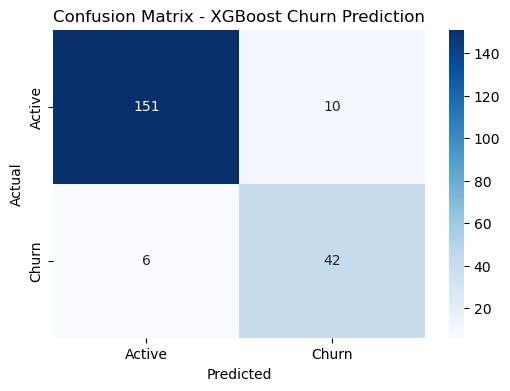

In [8]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Active', 'Churn'], yticklabels=['Active', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost Churn Prediction')
plt.show()

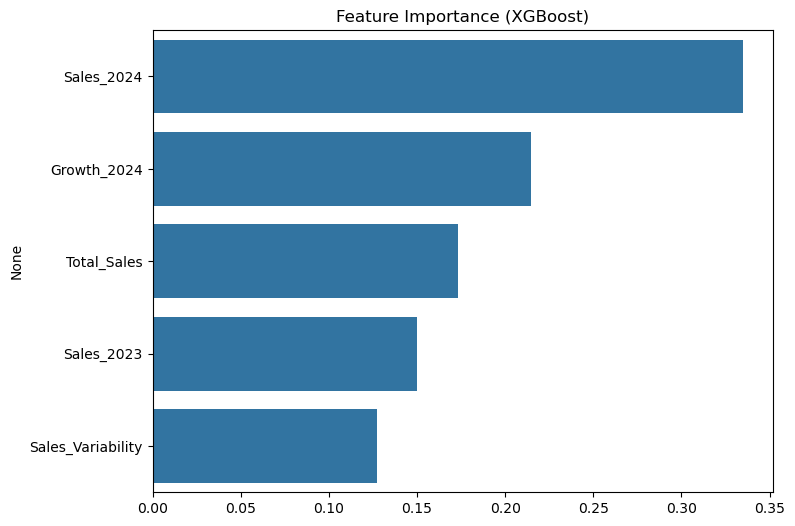

In [9]:
plt.figure(figsize=(8, 6))
importance = model.feature_importances_
features = X.columns
sorted_idx = np.argsort(importance)[::-1]

sns.barplot(x=importance[sorted_idx], y=features[sorted_idx])
plt.title('Feature Importance (XGBoost)')
plt.show()

In [10]:
df['Churn_Probability'] = model.predict_proba(scaler.transform(X))[:, 1]
df['Predicted_Churn'] = model.predict(scaler.transform(X))

# Save report
output_path = "C:/Users/joshd/Documents/ML Project Sem-7/xgboost_churn_prediction_report.csv"
df.to_csv(output_path, index=False)
print(f"✅ Churn prediction report saved as {output_path}")

✅ Churn prediction report saved as C:/Users/joshd/Documents/ML Project Sem-7/xgboost_churn_prediction_report.csv
